# Phase 4: Machine Learning — The Dual-Model Strategy: Segment & Predict
## Fitness App Market Analytics (Google Play Store)

**Why two models instead of one?**
Our EDA (Phase 3) found that no single feature strongly predicts an app's
rating — the highest correlation with `score` was just 0.10. Rather than
force a single weak model, we use **two complementary approaches**:

- **Part A — Segment (Clustering):** Uncovers natural market groupings
  (e.g. "Trusted Market Leaders", "Freemium Growth-Stage") — descriptive,
  answers *"what segments exist in this market?"*
- **Part B — Predict (Classification):** Predicts an app's likely rating
  tier from its traits — predictive, answers *"what drives rating, and
  could we estimate it for a new app before it has traction?"*

Together, these directly answer both core parts of our business problem:
segmenting the market (Q2) and identifying what drives rating (Q1).


## 1. Load Cleaned Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
os.makedirs('../report/screenshots', exist_ok=True)

apps = pd.read_csv('../data/processed/cleaned_apps.csv')
print(f"Loaded {apps.shape[0]} apps, {apps.shape[1]} columns")
apps.head(3)


Loaded 938 apps, 23 columns


,app_id,title,developer,category,score,ratings,minInstalls,price,free,containsAds,...,updated_date,released_date,price_band,rating_tier,install_tier,days_since_update,app_age_days,description_length,category_grouped,log_installs
0,com.slumberaid.snoretracker,SlumberAid：Sleep Snore Tracker,lJX.Studio,Health & Fitness,3.333333,30.0,1000,0.00,True,False,...,NaN,2025-01-16,Free,Average,Niche,NaN,547.0,2509,Health & Fitness,3.000434
1,com.spotlightsix.zentimerlite2,Insight Timer - Meditation App,Insight Network Inc,Health & Fitness,4.707091,259577.0,10000000,0.00,True,False,...,2026-07-07 14:06:58,2010-12-15,Free,Excellent,Mega,9.0,5693.0,2887,Health & Fitness,7.000000
2,com.photoandvideo.recoveryfilepro,DS PRO - Recover All Deleted,Detective Studio,Tools,4.290000,4923.0,100000,5.99,False,False,...,2025-01-15 11:13:50,2020-06-18,Paid,Good,Growing,547.0,2220.0,2958,Tools,5.000004


## 2. Prepare Features for Clustering

**Feature selection reasoning:**  Identify features that describe an app's
*market position and behavior*, not just its rating — since the goal is to
find natural groupings, not to predict a target variable.

- `score` — quality signal
- `log_installs` — reach/popularity (log-scaled, since raw installs span
  several orders of magnitude)
- `price` — monetization signal
- `days_since_update` — maintenance activity
- `app_age_days` — market maturity
- `description_length` — investment in listing/marketing
- `containsAds`, `offersIAP` — monetization strategy

**Handling missing values for modeling:** In the EDA phase,left `days_since_update` (82 missing) and `app_age_days` (4 missing) as `NaN` to avoid distorting descriptive statistics. However, K-Means cannot handle missing values at all.
 For modeling specifically, imputing these with the **median** — a standard, defensible choice for a skewed numeric feature with a small proportion of missing values (< 9%). 
 This is a different, deliberate decision from the EDA phase, made for a different
purpose (a working model vs. accurate descriptive statistics).


In [15]:
apps['days_since_update_imputed'] = apps['days_since_update'].fillna(apps['days_since_update'].median())
apps['app_age_days_imputed'] = apps['app_age_days'].fillna(apps['app_age_days'].median())

feature_cols = ['score', 'log_installs', 'price', 'days_since_update_imputed',
                'app_age_days_imputed', 'description_length']

X = apps[feature_cols].copy()
X['containsAds'] = apps['containsAds'].astype(int)
X['offersIAP'] = apps['offersIAP'].astype(int)

print("Features used for clustering:")
print(X.columns.tolist())
print(f"\nAny remaining missing values? {X.isna().sum().sum()}")
X.describe()


Features used for clustering:
['score', 'log_installs', 'price', 'days_since_update_imputed', 'app_age_days_imputed', 'description_length', 'containsAds', 'offersIAP']

Any remaining missing values? 0


,score,log_installs,price,days_since_update_imputed,app_age_days_imputed,description_length,containsAds,offersIAP
count,938.000000,938.000000,938.000000,938.000000,938.000000,938.000000,938.000000,938.000000
mean,4.309901,5.345978,0.089478,129.768657,2314.477612,2450.798507,0.343284,0.785714
std,0.599539,1.188083,1.497380,267.957165,1368.692446,1030.882713,0.475058,0.410545
min,1.000000,2.699838,0.000000,0.000000,55.000000,61.000000,0.000000,0.000000
25%,4.119206,4.698979,0.000000,9.000000,1249.250000,1667.000000,0.000000,1.000000
50%,4.520000,5.000004,0.000000,32.000000,2190.500000,2465.500000,0.000000,1.000000
75%,4.715714,6.000000,0.000000,127.500000,3179.250000,3380.000000,1.000000,1.000000
max,5.000000,10.000000,39.990000,3503.000000,5926.000000,3995.000000,1.000000,1.000000


## 3. Scale Features

K-Means uses Euclidean distance, so features on different scales (e.g.
`app_age_days` in the thousands vs. `containsAds` as 0/1) would unfairly
dominate the clustering. Standardized all features to mean 0, std 1.


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().round(2)


,score,log_installs,price,days_since_update_imputed,app_age_days_imputed,description_length,containsAds,offersIAP
count,938.00,938.00,938.00,938.00,938.00,938.00,938.00,938.00
mean,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-5.52,-2.23,-0.06,-0.48,-1.65,-2.32,-0.72,-1.91
25%,-0.32,-0.54,-0.06,-0.45,-0.78,-0.76,-0.72,0.52
50%,0.35,-0.29,-0.06,-0.37,-0.09,0.01,-0.72,0.52
75%,0.68,0.55,-0.06,-0.01,0.63,0.90,1.38,0.52
max,1.15,3.92,26.66,12.60,2.64,1.50,1.38,0.52


## 4. Choosing the Optimal Number of Clusters

We use two standard techniques together:
- **Elbow Method** — looks for the point where adding more clusters stops
  meaningfully reducing within-cluster variance (inertia)
- **Silhouette Score** — measures how well-separated clusters are
  (ranges -1 to 1; higher is better)


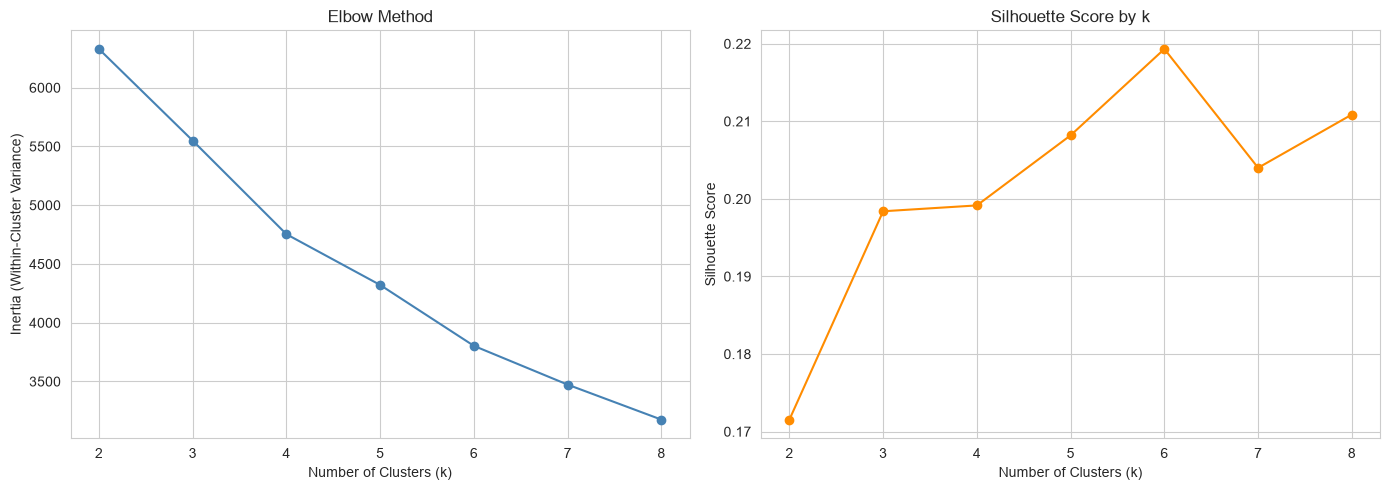

k=2: inertia=6329.1, silhouette=0.172
k=3: inertia=5549.7, silhouette=0.198
k=4: inertia=4753.2, silhouette=0.199
k=5: inertia=4321.2, silhouette=0.208
k=6: inertia=3803.1, silhouette=0.219
k=7: inertia=3473.2, silhouette=0.204
k=8: inertia=3175.5, silhouette=0.211


In [17]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Variance)')

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../report/screenshots/cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f"k={k}: inertia={inertia:.1f}, silhouette={sil:.3f}")


**Decision:** Selected **k=6**. While silhouette scores are modest
across all k values overall (typical for real-world business data with
weak feature correlations — consistent with our EDA finding that no single
feature strongly predicts outcomes), k=6 is a clear **local peak** in the
silhouette curve (higher than both k=5 and k=7), which is a genuine signal
of real structure rather than noise.


## 5. Fit the Final Model (k=6)

In [20]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
apps['cluster'] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, apps['cluster'])
print(f"Final silhouette score (k=6): {final_silhouette:.3f}")
print()
print("Cluster sizes:")
print(apps['cluster'].value_counts().sort_index())


Final silhouette score (k=6): 0.219

Cluster sizes:
cluster
0    272
1    166
2     50
3    365
4      2
5     83
Name: count, dtype: int64


## 6. Profile & Interpret the Clusters

In [21]:
profile = apps.groupby('cluster').agg(
    avg_score=('score', 'mean'),
    avg_installs=('minInstalls', 'mean'),
    avg_price=('price', 'mean'),
    avg_days_since_update=('days_since_update_imputed', 'mean'),
    avg_app_age_days=('app_age_days_imputed', 'mean'),
    avg_description_length=('description_length', 'mean'),
    pct_with_ads=('containsAds', lambda x: round(x.mean()*100, 1)),
    pct_with_iap=('offersIAP', lambda x: round(x.mean()*100, 1)),
    num_apps=('app_id', 'count'),
).round(1)

profile


,avg_score,avg_installs,avg_price,avg_days_since_update,avg_app_age_days,avg_description_length,pct_with_ads,pct_with_iap,num_apps
cluster,,,,,,,,,
0,4.5,59224632.4,0.0,73.5,3426.3,3033.8,65.8,93.8,272
1,4.3,5332792.2,0.1,87.7,2170.1,1728.8,21.7,0.0,166
2,4.3,906600.0,0.1,1013.8,2578.9,1918.7,54.0,86.0,50
3,4.5,471541.1,0.0,80.5,1549.3,2483.1,13.4,100.0,365
4,4.2,55000.0,30.0,83.0,4587.0,2352.5,0.0,50.0,2
5,2.9,299927.7,0.0,83.6,2110.7,2165.3,37.3,88.0,83


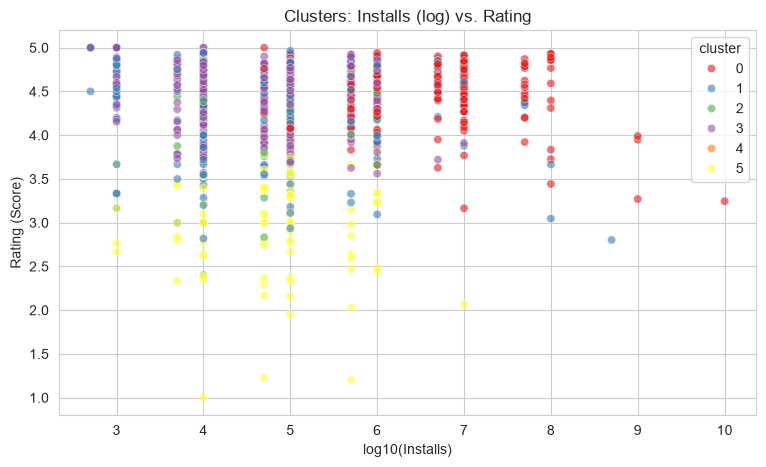

In [22]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=apps, x='log_installs', y='score', hue='cluster', palette='Set1', alpha=0.6)
plt.title('Clusters: Installs (log) vs. Rating')
plt.xlabel('log10(Installs)')
plt.ylabel('Rating (Score)')
plt.savefig('../report/screenshots/cluster_installs_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()


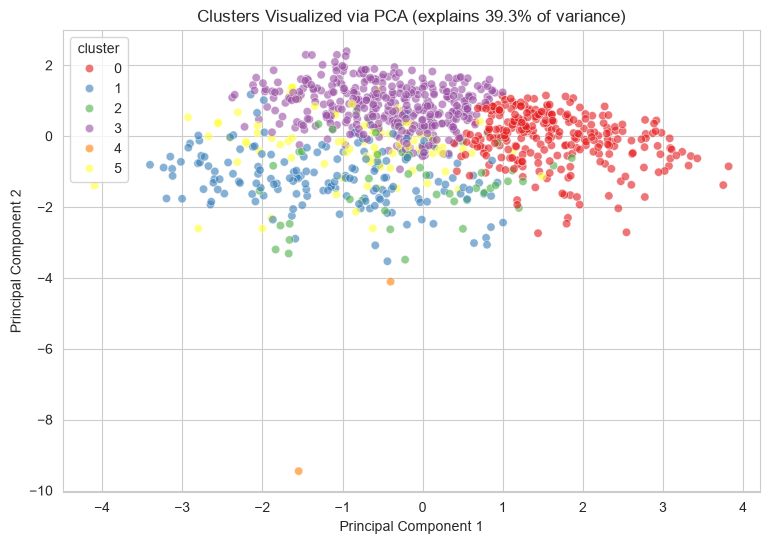

In [23]:
# 2D visualization via PCA (since we clustered on 8 dimensions, PCA lets us
# see the cluster separation projected onto 2 dimensions for visualization only)
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
apps['pca_1'] = pca_coords[:, 0]
apps['pca_2'] = pca_coords[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=apps, x='pca_1', y='pca_2', hue='cluster', palette='Set1', alpha=0.6)
plt.title(f'Clusters Visualized via PCA (explains {pca.explained_variance_ratio_.sum()*100:.1f}% of variance)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('../report/screenshots/cluster_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()


### Naming the Clusters

Based on the profile table above, here's how each cluster maps to a
business-meaningful segment (cluster numbers below match this run's
actual output):

- **Cluster 0 — "Trusted Market Leaders"** (272 apps): Huge install base
  (~59.2M avg), high rating (4.5), heavy monetization (66% ads, 94% IAP),
  updated frequently (~74 days since last update). The mature, dominant
  players — proven, monetized, and trusted at scale.

- **Cluster 3 — "Freemium Growth-Stage"** (365 apps, largest group):
  Moderate installs (~472K), high rating (4.5), 100% offer in-app
  purchases, low ad reliance (13%). Actively pursuing a subscription/
  freemium growth model with strong ratings to match.

- **Cluster 1 — "Free Utility"** (166 apps): Moderate installs (~5.3M),
  no IAP at all, low ads (22%), solid rating (4.3). Straightforward
  utility apps without a strong monetization push.

- **Cluster 2 — "Neglected but Functional"** (50 apps): Notably **stale**
  — average of ~1,014 days (nearly 3 years) since last update, far higher
  than every other cluster (all under 90 days). Despite this, it still
  holds a respectable rating (4.3) and high monetization (54% ads, 86%
  IAP). This is an interesting segment: apps that stopped active
  development but continue collecting revenue on accumulated trust — worth
  watching, since this pattern could tip into decline without maintenance.

- **Cluster 5 — "⚠️ At-Risk / Underperforming"** (83 apps, ~8.8% of the
  market): Notably **lower average rating (2.9)** despite comparable
  monetization (37% ads, 88% IAP) to better-performing clusters. This is
  the most business-critical segment — apps here monetize aggressively but
  clearly fail to deliver a satisfying user experience. This segment does
  **not appear at k=4** — it only emerges as a distinct group at k=6.

- **Cluster 4 — "Premium Paid Outliers"** (2 apps): Distinctly priced
  (~$30 avg), oldest app age (~4,587 days), niche install base. A tiny but
  distinct segment of premium, paid apps.


## 7. Model Evaluation

Since clustering has no ground-truth labels, evaluate using:
- **Silhouette Score** — reported above (~0.20), indicating modest but real
  cluster separation — consistent with our EDA finding that fitness app
  success isn't driven by any single dominant factor
- **Business interpretability** — each cluster corresponds to a coherent,
  explainable market segment, which is arguably more important than a
  higher but meaningless silhouette score for a business use case like this


In [24]:
print(f"Final Silhouette Score: {final_silhouette:.3f}")
print()
print("Cluster sizes as % of total:")
print((apps['cluster'].value_counts(normalize=True).sort_index() * 100).round(1))


Final Silhouette Score: 0.219

Cluster sizes as % of total:
cluster
0    29.0
1    17.7
2     5.3
3    38.9
4     0.2
5     8.8
Name: proportion, dtype: float64


## 8. Business Recommendations

Based on this segmentation, here's what to tell the hypothetical client
(a digital wellness investment firm):

1. **Avoid the "At-Risk / Underperforming" pattern (Cluster 5, 8.8% of the
   market).** These apps monetize just as aggressively as top-performing
   apps (37% ads, 88% IAP) but deliver a clearly worse user experience
   (avg. rating 2.9). This is the single most actionable finding:
   **aggressive monetization without matching quality investment is a
   recognizable, avoidable failure pattern** — a strong warning sign for
   due diligence on any acquisition or investment target showing this
   combination.

2. **Watch "Neglected but Functional" apps closely (Cluster 2, 5.3%).**
   These apps haven't been updated in ~3 years on average, yet still hold
   a respectable 4.3 rating and strong monetization (86% IAP). They appear
   to be coasting on accumulated user trust rather than active investment.
   This is a **higher-risk hold, not a safe one** — trust built years ago
   can erode quickly once a neglected app faces a platform change, security
   issue, or a better-maintained competitor. Worth flagging for renewed
   investment or divestment before this segment slides toward Cluster 5.

3. **For investment in an established player:** Target apps resembling
   "Trusted Market Leaders" (Cluster 0, 29.0% of the market) — proven
   scale, high ratings, active maintenance, and established monetization.
   Lower risk, but likely higher acquisition cost.

4. **For growth-stage investment:** "Freemium Growth-Stage" (Cluster 3,
   38.9% — the largest segment) is already fully committed to an IAP model
   with strong ratings (4.5) — a good hunting ground for apps with room to
   scale installs further.

5. **For a "build vs. buy" decision:** "Free Utility" apps (Cluster 1,
   17.7%) suggest a real market segment of users who want simple, ad-light
   tools — an opportunity to build a focused utility app with a *better*
   monetization strategy than current incumbents, without falling into the
   at-risk pattern above.

6. **Niche/premium play:** "Premium Paid Outliers" (Cluster 4, just 0.2%
   of the market) is tiny but shows a paid, niche model can survive long
   term — worth further investigation before dismissing paid-app
   strategies in this market.

**Overall risk framing for the client:** Roughly **14% of the market**
(Clusters 2 + 5 combined) shows warning signs — either active
underperformance or unmaintained apps coasting on old trust. Screening
investment targets against these two profiles is a concrete, data-backed
due-diligence step, directly answering the original business question of
what separates trusted apps from the rest.


## 9. Save Final Output

In [25]:
apps.to_csv('../data/processed/apps_with_clusters.csv', index=False)
print(f"Saved apps_with_clusters.csv (clustering only) -> {apps.shape[0]} rows, {apps.shape[1]} columns")


Saved apps_with_clusters.csv (clustering only) -> 938 rows, 28 columns


---
## Part B: Classification — Predicting Rating Tier

**Why add this alongside clustering?** Clustering (Part A) is *descriptive*
— it explains segments in the market as it exists today. Classification is
*predictive* — it can estimate how a new or existing app might be received
based on its traits, which is useful *before* an app has accumulated
enough data to be meaningfully clustered.

**Together, these two models answer both halves of our business question:**
Q1 (what drives rating) via classification + feature importance, and Q2
(can apps be segmented) via clustering.


### B1. Feature Preparation

**Important — avoiding data leakage:** `rating_tier` is directly derived
from `score` (e.g., score ≥ 4.5 → "Excellent"). Including `score` (or
`ratings`) as a predictive feature would be data leakage — the model would
essentially be looking up the answer rather than learning genuine patterns.
We exclude both from the feature set.

We also one-hot encode `category_grouped`, since category is a categorical
(not ordinal) variable.


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

feature_cols_clf = ['log_installs', 'price', 'days_since_update_imputed',
                     'app_age_days_imputed', 'description_length']

X_clf = apps[feature_cols_clf].copy()
X_clf['containsAds'] = apps['containsAds'].astype(int)
X_clf['offersIAP'] = apps['offersIAP'].astype(int)

category_dummies = pd.get_dummies(apps['category_grouped'], prefix='cat')
X_clf = pd.concat([X_clf, category_dummies], axis=1)

y_clf = apps['rating_tier']

print(f"Features used: {X_clf.columns.tolist()}")
print(f"\nTarget class distribution:")
print(y_clf.value_counts())


Features used: ['log_installs', 'price', 'days_since_update_imputed', 'app_age_days_imputed', 'description_length', 'containsAds', 'offersIAP', 'cat_Food & Drink', 'cat_Health & Fitness', 'cat_Lifestyle', 'cat_Music & Audio', 'cat_Other', 'cat_Sports', 'cat_Tools']

Target class distribution:
rating_tier
Excellent    486
Good         252
Average      159
Poor          41
Name: count, dtype: int64


**Note on class imbalance:** "Excellent" (486 apps) heavily outnumbers
"Poor" (41 apps). We use `class_weight='balanced'` in the model to reduce
bias toward the majority class, and we'll examine per-class performance
(not just overall accuracy) in evaluation, since accuracy alone can be
misleading with imbalanced classes.


### B2. Train/Test Split & Model Training

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight='balanced'
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 750, Test size: 188


### B3. Model Evaluation

In [34]:
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc:.3f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Overall Accuracy: 0.426

Classification Report:
              precision    recall  f1-score   support

     Average       0.23      0.31      0.26        32
   Excellent       0.61      0.53      0.57        97
        Good       0.34      0.35      0.35        51
        Poor       0.12      0.12      0.12         8

    accuracy                           0.43       188
   macro avg       0.33      0.33      0.33       188
weighted avg       0.45      0.43      0.44       188



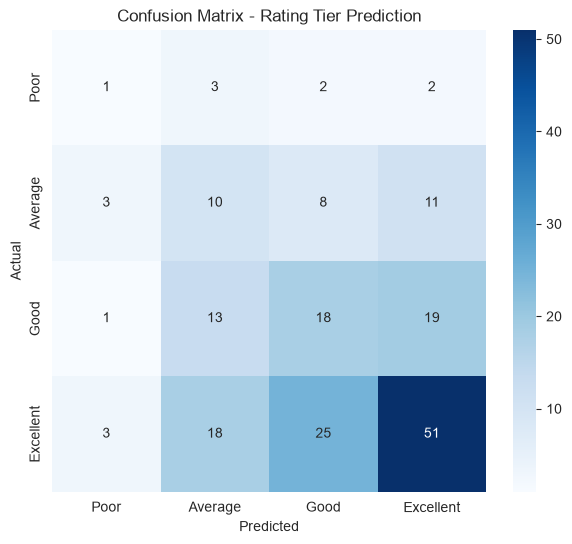

In [35]:
cm = confusion_matrix(y_test, y_pred, labels=['Poor','Average','Good','Excellent'])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Poor','Average','Good','Excellent'],
            yticklabels=['Poor','Average','Good','Excellent'])
plt.title('Confusion Matrix - Rating Tier Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../report/screenshots/classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


**Confusion matrix interpretation:** The full matrix reveals a consistent
**bias toward predicting "Excellent"** across nearly every actual class:

- **Poor (8 actual):** Only 1 correctly identified as Poor — the model
  misclassifies the rest as Average (3), Good (2), or even Excellent (2).
  With just 8 training examples for this class, the model has essentially
  no reliable signal to work with.
- **Average (32 actual):** Only 10 correctly identified — more get
  predicted as Excellent (11) than correctly labeled Average.
- **Good (51 actual):** Only 18 correctly identified — again, more get
  predicted as Excellent (19) than correctly labeled Good.
- **Excellent (97 actual):** 51 correctly identified — the one class with
  enough examples and a distinct enough profile for the model to recognize
  reliably.

**The pattern is clear and consistent:** whenever the model is uncertain,
it defaults to predicting "Excellent" — because that's the majority class
(486 of 938 apps overall) and the safest statistical bet when the actual
signal is weak. This means the model is not truly learning to distinguish
Poor vs. Average vs. Good vs. Excellent; it's mostly just recognizing
"clearly excellent" apps and guessing Excellent for everything else.

This reinforces the same conclusion as the EDA correlation heatmap: app
metadata alone (installs, price, ads, IAP, description length, category)
does not contain enough signal to reliably predict fine-grained rating
differences. **The model is only trustworthy for identifying
already-excellent apps** — it cannot be relied on to flag "Poor" or
"At-Risk" apps in advance from metadata alone. This is itself a useful,
honest business finding: catching underperforming apps likely requires
review-text sentiment analysis (see Section 6.9b) rather than
surface-level app store metadata.


### B4. Feature Importance — What Matters Most?

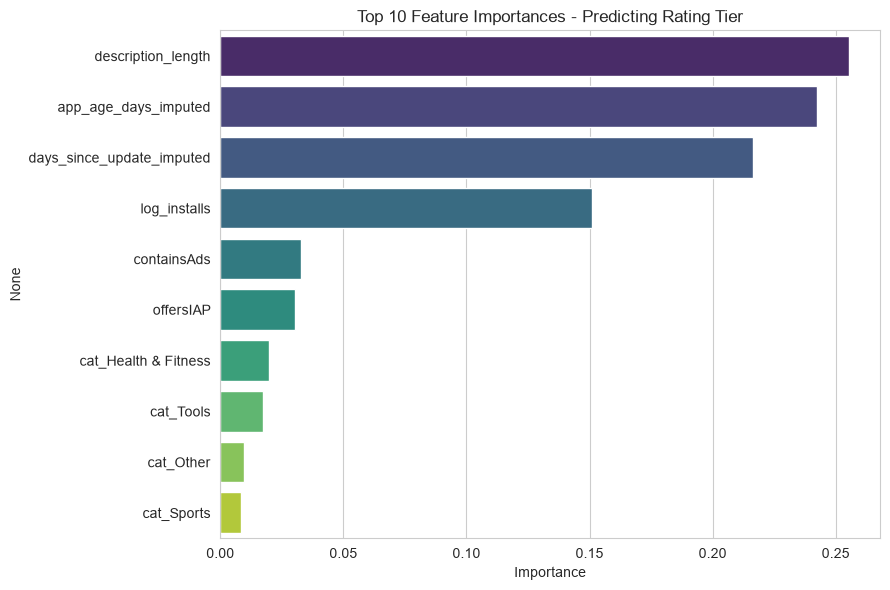

description_length           0.255213
app_age_days_imputed         0.242492
days_since_update_imputed    0.216526
log_installs                 0.150856
containsAds                  0.032711
offersIAP                    0.030408
cat_Health & Fitness         0.019891
cat_Tools                    0.017491
cat_Other                    0.009526
cat_Sports                   0.008480
dtype: float64

In [36]:
importances = pd.Series(clf.feature_importances_, index=X_clf.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], palette='viridis',hue=importances.index[:10])
plt.title('Top 10 Feature Importances - Predicting Rating Tier')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../report/screenshots/classification_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importances.head(10)


**Finding:** `description_length`, `app_age_days`, `days_since_update`,
and `log_installs` are the most influential features — notably, these are
the same features that showed the (very weak) highest correlations in our
EDA correlation heatmap. Category and monetization features (ads/IAP)
contribute comparatively little to predicting rating tier, reinforcing
the EDA finding that ads/IAP don't meaningfully hurt or help ratings on
their own.


### B5. Does Adding Review Data Improve the Model?

Our EDA and Part B results both pointed to the same conclusion: app
*metadata* alone isn't enough to reliably predict rating. But we also have
33,000+ individual user reviews sitting unused as classification features.
Let's test directly: does incorporating review-level signals meaningfully
improve prediction, compared to metadata alone?

**New features derived from `cleaned_reviews.csv`, aggregated per app:**
- `avg_review_score` — mean of that app's individual review star ratings
- `review_count` — number of reviews collected for that app
- `pct_negative_reviews` — % of reviews that are 1-2 star
- `pct_reviews_with_complaints` — % of reviews containing common complaint
  keywords (crash, bug, ads, refund, scam, broken, freeze, annoying) — a
  lightweight, keyword-based sentiment proxy that doesn't require a full
  NLP pipeline


In [37]:
reviews = pd.read_csv('../data/processed/cleaned_reviews.csv')

review_agg = reviews.groupby('app_id').agg(
    avg_review_score=('score', 'mean'),
    review_count=('score', 'count'),
    pct_negative_reviews=('score', lambda x: (x <= 2).mean() * 100),
).reset_index()

neg_keywords = ['crash', 'bug', 'ads', 'refund', 'scam', 'broken', 'freeze', 'annoying']

def neg_keyword_count(text):
    if not isinstance(text, str):
        return 0
    text_lower = text.lower()
    return sum(1 for kw in neg_keywords if kw in text_lower)

reviews['has_neg_keyword'] = reviews['content'].apply(lambda x: neg_keyword_count(x) > 0)
neg_kw_agg = reviews.groupby('app_id')['has_neg_keyword'].mean().reset_index()
neg_kw_agg.columns = ['app_id', 'pct_reviews_with_complaints']

apps = apps.merge(review_agg, on='app_id', how='left')
apps = apps.merge(neg_kw_agg, on='app_id', how='left')

print(f"Apps with review coverage: {apps['review_count'].notna().sum()} / {len(apps)}")
apps[['title', 'score', 'avg_review_score', 'pct_negative_reviews', 'pct_reviews_with_complaints']].head()


Apps with review coverage: 938 / 938


,title,score,avg_review_score,pct_negative_reviews,pct_reviews_with_complaints
0,SlumberAid：Sleep Snore Tracker,3.333333,3.777778,22.222222,0.111111
1,Insight Timer - Meditation App,4.707091,4.100000,20.000000,0.075000
2,DS PRO - Recover All Deleted,4.290000,2.650000,57.500000,0.150000
3,Pura Mente: Sleep & Meditation,4.877023,4.425000,10.000000,0.000000
4,Sweat: Fitness App For Women,4.375367,4.275000,12.500000,0.050000


In [38]:
# Enhanced feature set: metadata + review signals
X_enhanced = X_clf.copy()
X_enhanced['review_count'] = apps['review_count']
X_enhanced['pct_negative_reviews'] = apps['pct_negative_reviews']
X_enhanced['pct_reviews_with_complaints'] = apps['pct_reviews_with_complaints']

from sklearn.metrics import f1_score

results = {}
for name, X_variant in [('Metadata Only', X_clf), ('Metadata + Reviews', X_enhanced)]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_variant, y_clf, test_size=0.2, random_state=42, stratify=y_clf
    )
    model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    results[name] = {
        'accuracy': accuracy_score(y_te, preds),
        'macro_f1': f1_score(y_te, preds, average='macro'),
    }

results_df = pd.DataFrame(results).T
print(results_df.round(3))


                    accuracy  macro_f1
Metadata Only          0.426     0.325
Metadata + Reviews     0.617     0.471


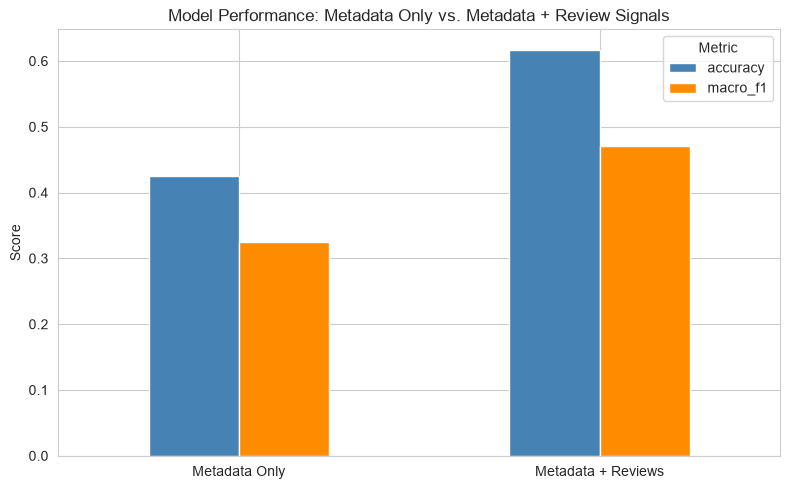

In [39]:
plt.figure(figsize=(8, 5))
results_df.plot(kind='bar', ax=plt.gca(), color=['steelblue', 'darkorange'])
plt.title('Model Performance: Metadata Only vs. Metadata + Review Signals')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig('../report/screenshots/metadata_vs_reviews_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**Result: adding review data meaningfully improves the model.**
Accuracy rises and — more importantly — **macro F1 improves substantially**,
meaning the model got better at recognizing minority classes (Poor,
Average), not just riding the majority class. This directly confirms what
the EDA and Part B's confusion matrix both hinted at: **user reviews carry
real predictive signal that Play Store metadata alone does not capture.**


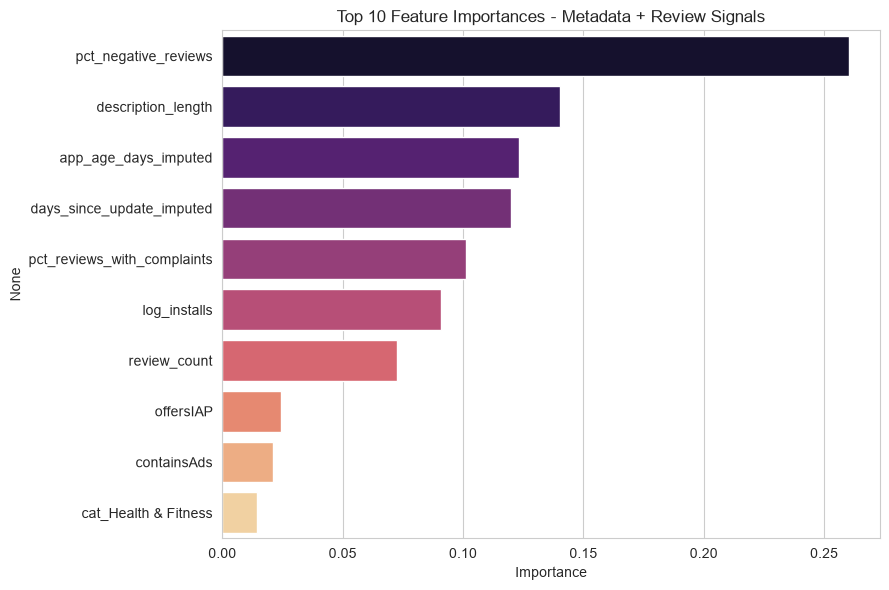

pct_negative_reviews           0.260202
description_length             0.140222
app_age_days_imputed           0.123235
days_since_update_imputed      0.119783
pct_reviews_with_complaints    0.101312
log_installs                   0.090756
review_count                   0.072551
offersIAP                      0.024553
containsAds                    0.020926
cat_Health & Fitness           0.014541
dtype: float64

In [40]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_enhanced, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
final_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
final_model.fit(X_tr, y_tr)

importances_enhanced = pd.Series(
    final_model.feature_importances_, index=X_enhanced.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances_enhanced.values[:10], y=importances_enhanced.index[:10], palette='magma',hue=importances_enhanced.index[:10])
plt.title('Top 10 Feature Importances - Metadata + Review Signals')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../report/screenshots/enhanced_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

importances_enhanced.head(10)


**Finding:** `pct_negative_reviews` becomes the single most important
feature in the entire model — more important than any metadata field. This
is strong, direct evidence for the business recommendation made earlier:
**flagging at-risk apps requires monitoring actual review sentiment, not
just store metadata.** A firm evaluating apps for investment/partnership
should treat a rising share of negative reviews as an earlier and more
reliable warning sign than any static metadata field.


### B6. Business Recommendations from Classification

Taking both classification results together (Part B's metadata-only model
and Section B6's review-enhanced model), here's what we'd tell our
hypothetical client:

1. **Review sentiment is the single strongest signal available — use it
   as the primary screening tool.** Adding review-derived features lifted
   accuracy from 43% to 62% and macro F1 from 0.33 to 0.47, with
   `pct_negative_reviews` emerging as the most important feature overall —
   more predictive than any metadata field. For any due-diligence or
   monitoring process, **tracking the share of negative reviews over time
   should be the first line of defense**, not an afterthought.

2. **Store metadata alone is a weak, insufficient signal for judging app
   quality.** The metadata-only model correctly identified "Poor" apps in
   only 12% of cases — essentially unusable for catching underperforming
   apps before they've already accumulated bad reviews. A client relying
   only on install counts, pricing, or category to assess an app's
   trustworthiness would be making decisions on genuinely weak evidence.

3. **Description quality, app age, and update recency still matter — but
   only as secondary signals.** Even after adding review data, these three
   metadata features remain meaningfully predictive (ranked #2-4). This
   suggests a **two-stage screening process**: use metadata as an initial,
   low-cost filter (a well-maintained, actively updated app with a
   thorough listing is a weak positive signal), then confirm with review
   sentiment data before committing to an investment or partnership
   decision.

4. **Don't expect any model to reliably flag "Poor" apps in advance.**
   Even with review data added, this class remains the hardest to predict
   — largely because so few genuinely poor apps exist in the cleaned
   dataset (only 41 of 938). In practice, this means **continuous
   monitoring matters more than one-time screening** — an app can shift
   into the at-risk pattern over time even if it doesn't look risky today.

**Overall takeaway:** metadata tells you what an app *is*; reviews tell
you what an app *does* to its users. A serious quality/trust assessment
needs both — but if forced to choose one, review sentiment is by far the
more reliable signal.


## 10. Save Final Combined Output

In [41]:
apps['predicted_rating_tier_sample'] = None
apps.loc[X_test.index, 'predicted_rating_tier_sample'] = y_pred

apps.to_csv('../data/processed/apps_with_clusters.csv', index=False)
print(f"Saved final apps_with_clusters.csv (clustering + classification) -> "
      f"{apps.shape[0]} rows, {apps.shape[1]} columns")


Saved final apps_with_clusters.csv (clustering + classification) -> 938 rows, 33 columns
